# Initial investigation

Dataset: `goodreads_books.json` — 8.6 GB JSONL, ~2.36M book records from Goodreads.  
We stream the first 100 000 records for exploration to avoid loading the full file into memory.

## 1. Imports & config

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATASET_PATH = Path("goodreads_books.json")
SAMPLE_SIZE = 100_000

## 2. Load sample

In [2]:
records = []
with open(DATASET_PATH) as f:
    for line in tqdm(f, total=SAMPLE_SIZE, desc="Loading"):
        records.append(json.loads(line))
        if len(records) >= SAMPLE_SIZE:
            break

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} records.  Full dataset: ~2,360,655 books (8.6 GB)")

Loading:   0%|          | 0/100000 [00:00<?, ?it/s]

Loaded 100,000 records.  Full dataset: ~2,360,655 books (8.6 GB)


## 3. Schema & dtypes

In [3]:
# Cast numeric columns that arrive as strings
numeric_cols = ["average_rating", "ratings_count", "text_reviews_count", "num_pages",
                "publication_year", "publication_month", "publication_day"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   isbn                  100000 non-null  object 
 1   text_reviews_count    99981 non-null   float64
 2   series                100000 non-null  object 
 3   country_code          100000 non-null  object 
 4   language_code         100000 non-null  object 
 5   popular_shelves       100000 non-null  object 
 6   asin                  100000 non-null  object 
 7   is_ebook              100000 non-null  object 
 8   average_rating        99981 non-null   float64
 9   kindle_asin           100000 non-null  object 
 10  similar_books         100000 non-null  object 
 11  description           100000 non-null  object 
 12  format                100000 non-null  object 
 13  link                  100000 non-null  object 
 14  authors               100000 non-null  object 
 15  p

In [4]:
df.head(3)

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,0312853122,1.0,[],US,,"[{'count': '3', 'name': 'to-read'}, {'count': ...",,false,4.00,,...,9.0,,1984.0,https://www.goodreads.com/book/show/5333265-w-...,https://images.gr-assets.com/books/1310220028m...,5333265,3.0,5400751,W.C. Fields: A Life on Film,W.C. Fields: A Life on Film
1,0743509986,6.0,[],US,,"[{'count': '2634', 'name': 'to-read'}, {'count...",,false,3.23,B000FC0PBC,...,10.0,Abridged,2001.0,https://www.goodreads.com/book/show/1333909.Go...,https://s.gr-assets.com/assets/nophoto/book/11...,1333909,10.0,1323437,Good Harbor,Good Harbor
2,,7.0,[189911],US,eng,"[{'count': '58', 'name': 'to-read'}, {'count':...",B00071IKUY,false,4.03,,...,NaN,Book Club Edition,1987.0,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...,7327624,140.0,8948723,"The Unschooled Wizard (Sun Wolf and Starhawk, ...","The Unschooled Wizard (Sun Wolf and Starhawk, ..."


## 4. Missing data

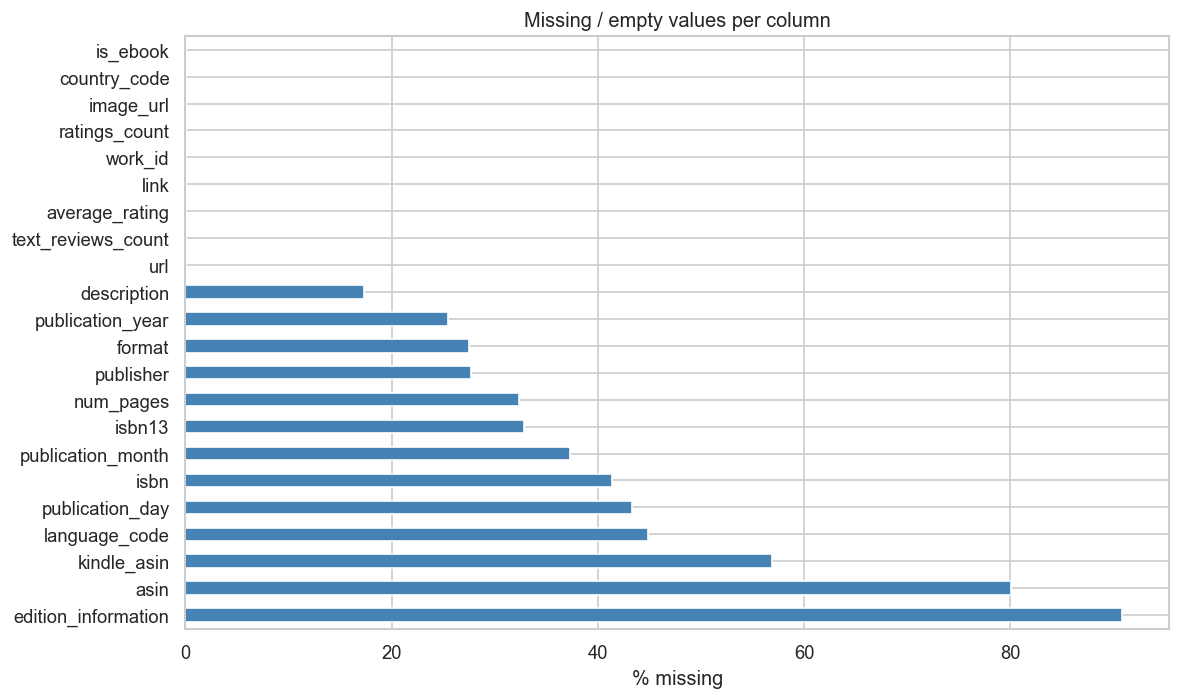

edition_information    90.8
asin                   80.1
kindle_asin            56.9
language_code          44.9
publication_day        43.3
isbn                   41.4
publication_month      37.3
isbn13                 32.8
num_pages              32.4
publisher              27.6
format                 27.5
publication_year       25.4
description            17.3
url                     0.0
text_reviews_count      0.0
average_rating          0.0
link                    0.0
work_id                 0.0
ratings_count           0.0
image_url               0.0
country_code            0.0
is_ebook                0.0


In [5]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
# Also treat empty strings as missing for object columns
for col in df.select_dtypes("object").columns:
    empty_pct = (df[col].astype(str).str.strip() == "").mean() * 100
    missing[col] = max(missing[col], empty_pct)
missing = missing.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
missing[missing > 0].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Missing / empty values per column")
plt.tight_layout()
plt.show()

print(missing[missing > 0].round(1).to_string())

## 5. Numerical statistics

In [6]:
df[numeric_cols].describe().round(2)

,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,publication_month,publication_day
count,99981.00,99981.00,99981.00,67624.00,74553.00,62698.00,56720.00
mean,3.87,399.71,29.51,276.30,2007.53,6.45,12.09
std,0.54,8288.50,338.33,3638.02,281.16,3.41,10.00
min,0.00,0.00,0.00,0.00,0.00,1.00,1.00
25%,3.63,6.00,2.00,147.00,2004.00,4.00,1.00
50%,3.91,21.00,4.00,246.00,2011.00,6.00,11.00
75%,4.16,81.00,12.00,344.00,2014.00,9.00,21.00
max,5.00,1848782.00,53601.00,945077.00,65535.00,12.00,31.00


## 6. Rating distribution

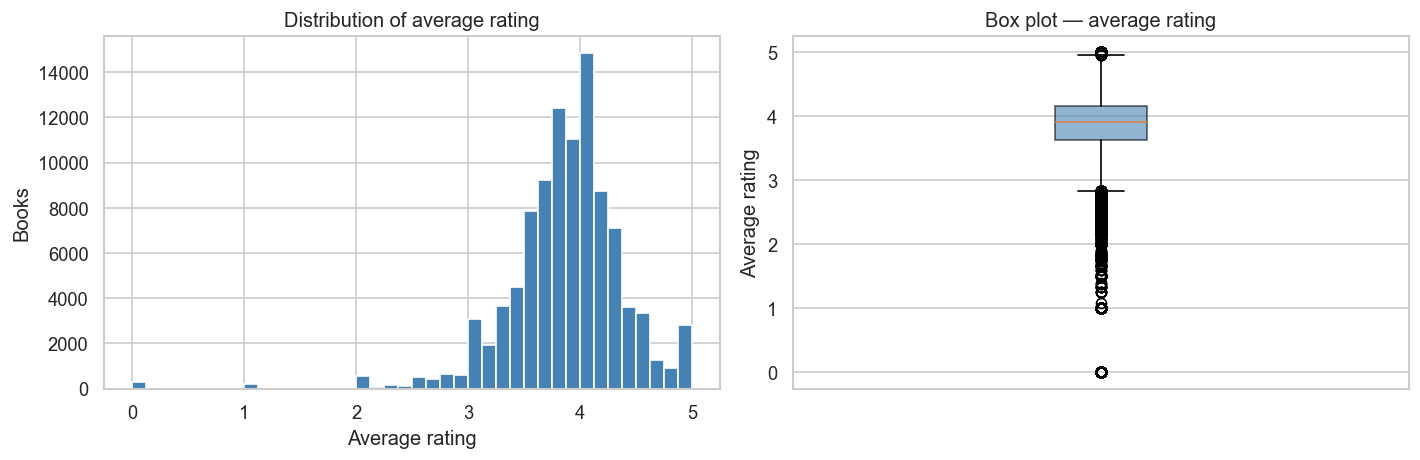

Mean: 3.866  |  Median: 3.910  |  Std: 0.536


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df["average_rating"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Average rating")
axes[0].set_ylabel("Books")
axes[0].set_title("Distribution of average rating")

# Box plot
axes[1].boxplot(df["average_rating"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Average rating")
axes[1].set_title("Box plot — average rating")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

r = df["average_rating"].dropna()
print(f"Mean: {r.mean():.3f}  |  Median: {r.median():.3f}  |  Std: {r.std():.3f}")

## 7. Ratings count — long-tail distribution

The vast majority of books have very few ratings; a small number of bestsellers dominate.  
This is the classic **long-tail** pattern common in recommendation datasets.

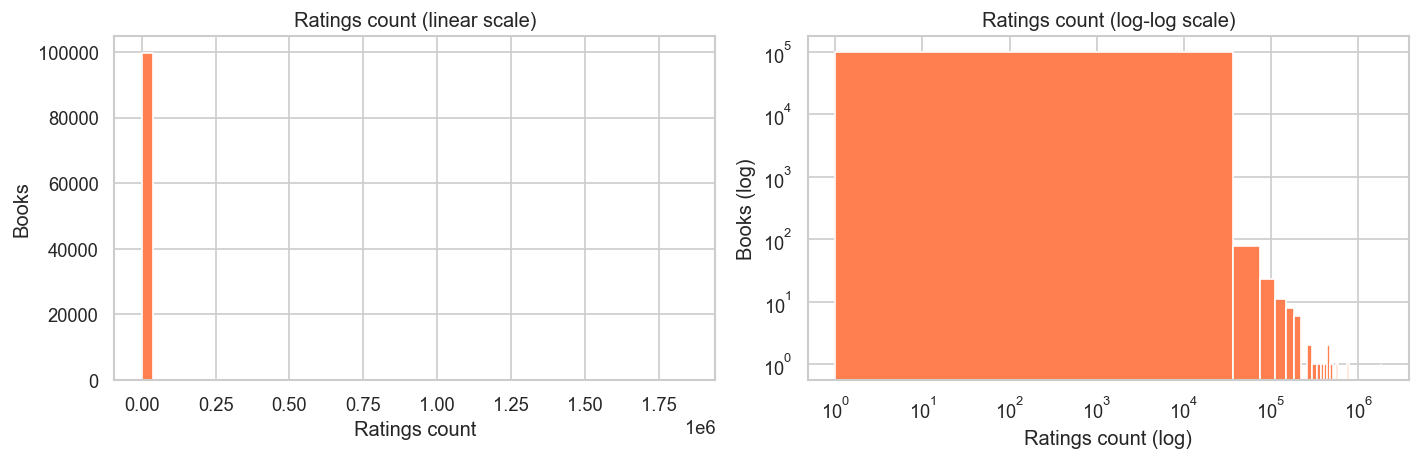

Mean: 400  |  Median: 21  |  Max: 1,848,782
Books with < 10 ratings: 34.1%
Books with < 100 ratings: 78.0%


In [8]:
rc = df["ratings_count"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rc, bins=50, color="coral", edgecolor="white")
axes[0].set_xlabel("Ratings count")
axes[0].set_ylabel("Books")
axes[0].set_title("Ratings count (linear scale)")

axes[1].hist(rc[rc > 0], bins=50, color="coral", edgecolor="white", log=True)
axes[1].set_xscale("log")
axes[1].set_xlabel("Ratings count (log)")
axes[1].set_ylabel("Books (log)")
axes[1].set_title("Ratings count (log-log scale)")

plt.tight_layout()
plt.show()

print(f"Mean: {rc.mean():,.0f}  |  Median: {rc.median():,.0f}  |  Max: {rc.max():,.0f}")
print(f"Books with < 10 ratings: {(rc < 10).mean():.1%}")
print(f"Books with < 100 ratings: {(rc < 100).mean():.1%}")

## 8. Publication timeline

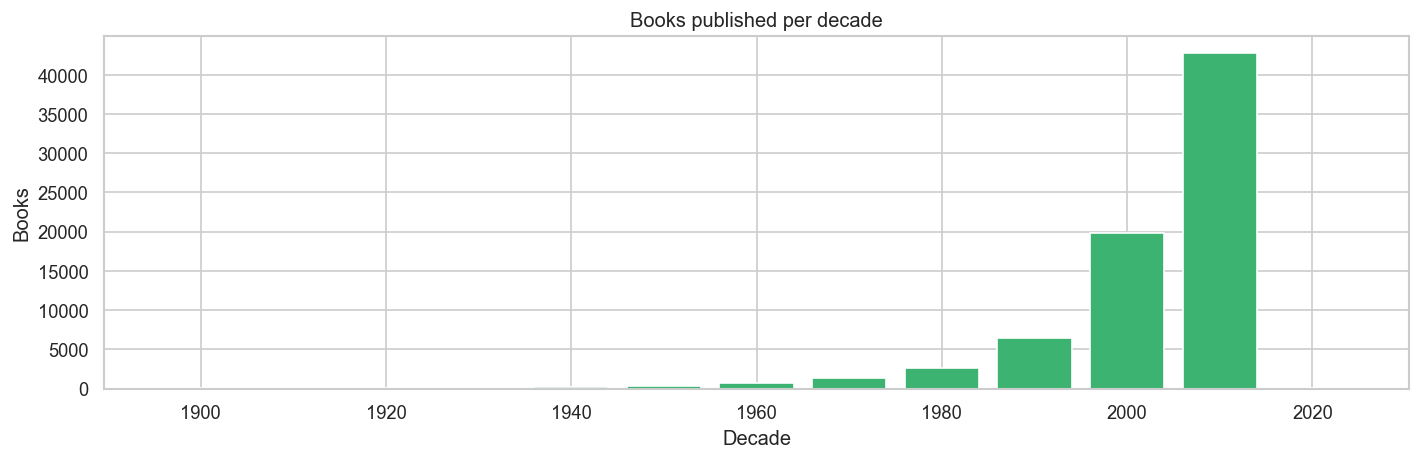

Year range: 1900 – 2020  |  Median: 2011


In [9]:
years = df["publication_year"].dropna()
years = years[(years >= 1900) & (years <= 2024)]

# Group by decade
decades = (years // 10 * 10).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(decades.index, decades.values, width=8, color="mediumseagreen", edgecolor="white")
ax.set_xlabel("Decade")
ax.set_ylabel("Books")
ax.set_title("Books published per decade")
plt.tight_layout()
plt.show()

print(f"Year range: {years.min():.0f} – {years.max():.0f}  |  Median: {years.median():.0f}")

## 9. Language distribution

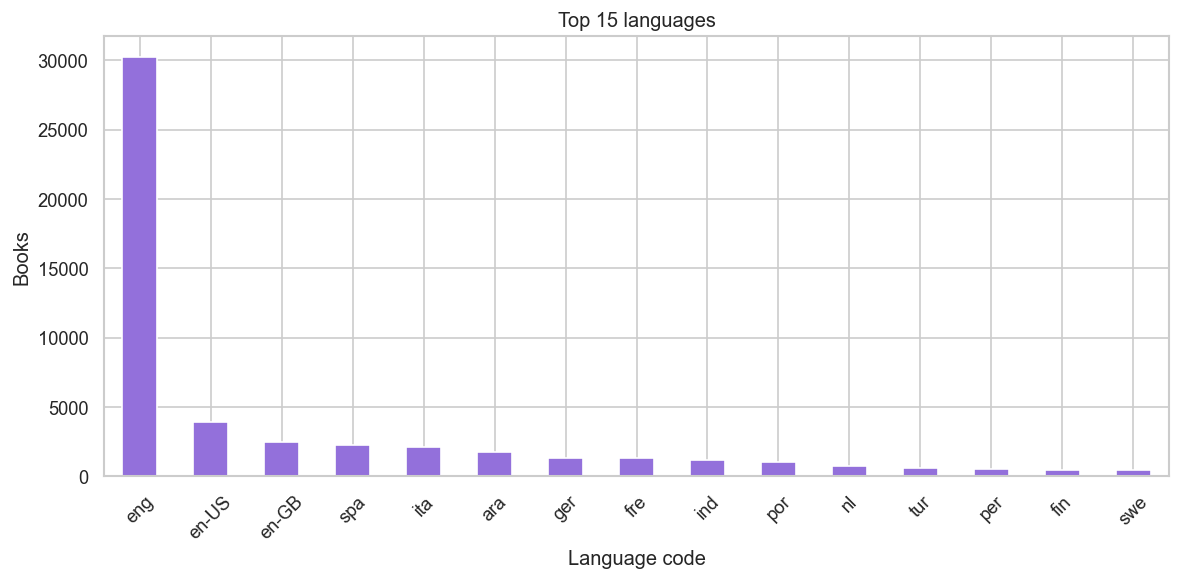

English (eng + en-US + en-GB) coverage: 66.4% of labelled books


In [10]:
lang = df["language_code"].replace("", np.nan).dropna()
top_lang = lang.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_lang.plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="white")
ax.set_xlabel("Language code")
ax.set_ylabel("Books")
ax.set_title("Top 15 languages")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"English (eng + en-US + en-GB) coverage: "
      f"{lang.isin(['eng','en-US','en-GB']).mean():.1%} of labelled books")

## 10. Book formats

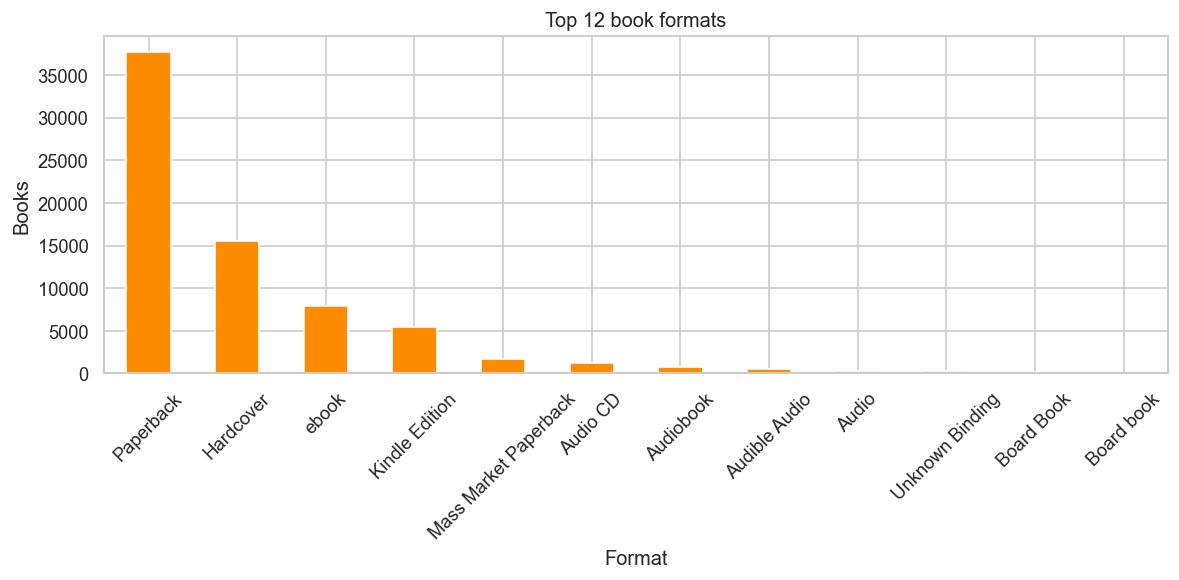

In [11]:
fmt = df["format"].replace("", np.nan).dropna()
top_fmt = fmt.value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top_fmt.plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_xlabel("Format")
ax.set_ylabel("Books")
ax.set_title("Top 12 book formats")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 11. Popular shelves — implicit feedback signal

`popular_shelves` records how many users placed each book on a named shelf.  
This is the primary **implicit feedback** signal available in the dataset and can be used to derive user–item interactions for collaborative filtering.

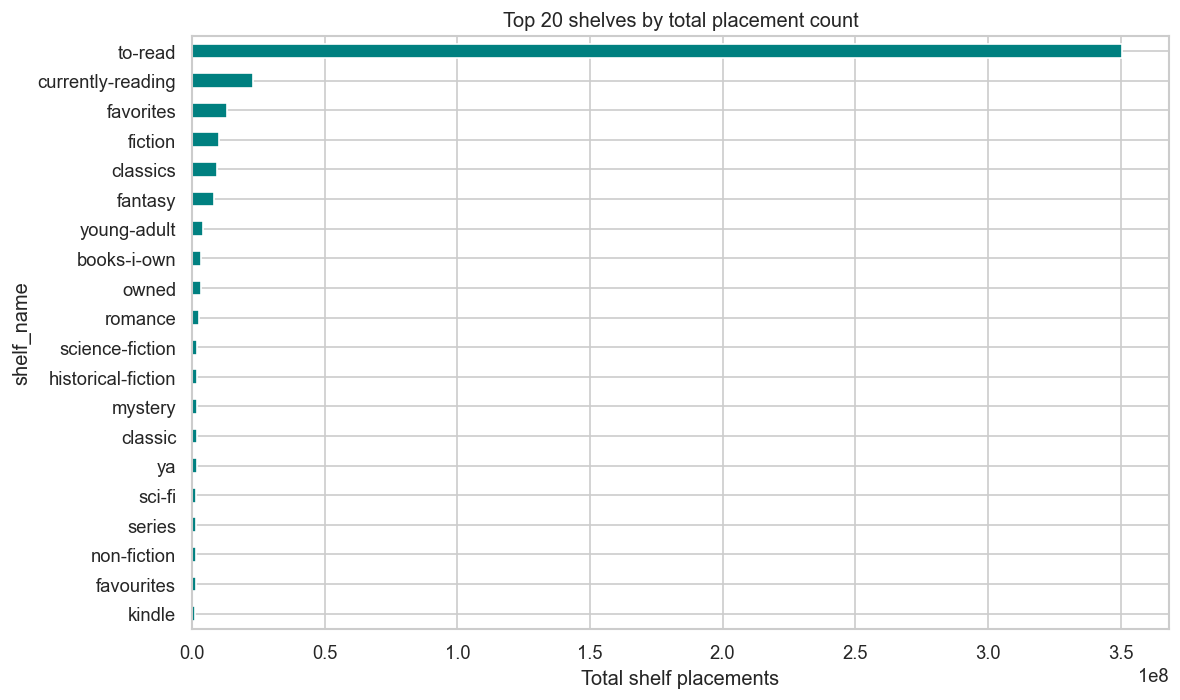

In [12]:
shelves_exploded = (
    df[["book_id", "popular_shelves"]]
    .explode("popular_shelves")
    .dropna(subset=["popular_shelves"])
)
shelves_exploded["shelf_name"] = shelves_exploded["popular_shelves"].apply(
    lambda x: x.get("name") if isinstance(x, dict) else None
)
shelves_exploded["shelf_count"] = shelves_exploded["popular_shelves"].apply(
    lambda x: int(x.get("count", 0)) if isinstance(x, dict) else 0
)

top_shelves = (
    shelves_exploded.groupby("shelf_name")["shelf_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_shelves.plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("Total shelf placements")
ax.set_title("Top 20 shelves by total placement count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Key takeaways for recommender training

| Observation | Implication |
|---|---|
| ~2.36 M books, 8.6 GB JSONL | Stream or chunk on load; convert a filtered subset to Parquet for fast iteration |
| `popular_shelves` — implicit feedback | Primary signal for collaborative filtering (user → shelf → book) |
| Ratings highly skewed (median ≈ 24, mean ≈ 459) | Apply popularity threshold before CF training to avoid cold-start noise |
| Rich text fields (`description`, `popular_shelves`) | Content-based & hybrid models are well supported |
| `similar_books` links | Can seed a graph-based or item-KNN approach |
| English dominates | Filter to `language_code in ['eng', 'en-US', 'en-GB']` for a cleaner English-only experiment |

**Next steps:**  
1. Convert a filtered, English-only subset to Parquet  
2. Train a baseline popularity model  
3. Train collaborative filtering models via `recommenders` (e.g. SAR, ALS, SVD++)  
4. Evaluate with `recommenders.evaluation` (NDCG, MAP, precision@k)

# Interaction Data Investigation

We now have three additional files that contain per-user interaction data:

| File | Size | Rows | Description |
|---|---|---|---|
| `goodreads_interactions.csv` | 4.0 GB | ~228.6 M | `user_id`, `book_id`, `is_read`, `rating` (0–5), `is_reviewed` |
| `user_id_map.csv` | 33 MB | ~876 K | sequential `user_id_csv` → original MD5 hash user ID |
| `book_id_map.csv` | 36 MB | ~2.36 M | sequential `book_id_csv` → original Goodreads `book_id` |

**Join chain** to resolve interaction `book_id` → `work_id`:
```
interactions.book_id → book_id_map.book_id_csv → book_id_map.book_id
                     → goodreads_books.book_id → work_id
```

In [13]:
# Load the two small map files (fit easily in memory)
user_map = pd.read_csv("user_id_map.csv")
book_map = pd.read_csv("book_id_map.csv")

print(f"Unique users : {len(user_map):>10,}")
print(f"Unique books : {len(book_map):>10,}")
print()
display(user_map.head(3))
display(book_map.head(3))

Unique users :    876,145
Unique books :  2,360,650



,user_id_csv,user_id
0,0,8842281e1d1347389f2ab93d60773d4d
1,1,72fb0d0087d28c832f15776b0d936598
2,2,ab2923b738ea3082f5f3efcbbfacb218


,book_id_csv,book_id
0,0,34684622
1,1,34536488
2,2,34017076


In [14]:
# Sample the interactions file — read first 500 000 rows
# (full file is 4 GB / 228 M rows; chunked loading needed for full training)
interactions_sample = pd.read_csv("goodreads_interactions.csv", nrows=500_000)
print(f"Sample shape: {interactions_sample.shape}")
interactions_sample.info()
display(interactions_sample.head())

Sample shape: (500000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   user_id      500000 non-null  int64
 1   book_id      500000 non-null  int64
 2   is_read      500000 non-null  int64
 3   rating       500000 non-null  int64
 4   is_reviewed  500000 non-null  int64
dtypes: int64(5)
memory usage: 19.1 MB


,user_id,book_id,is_read,rating,is_reviewed
0,0,948,1,5,0
1,0,947,1,5,1
2,0,946,1,5,0
3,0,945,1,5,0
4,0,944,1,5,0


### Rating distribution

`rating = 0` means the user interacted (shelved / read) but left **no explicit rating**.  
`rating = 1–5` is an explicit star rating.

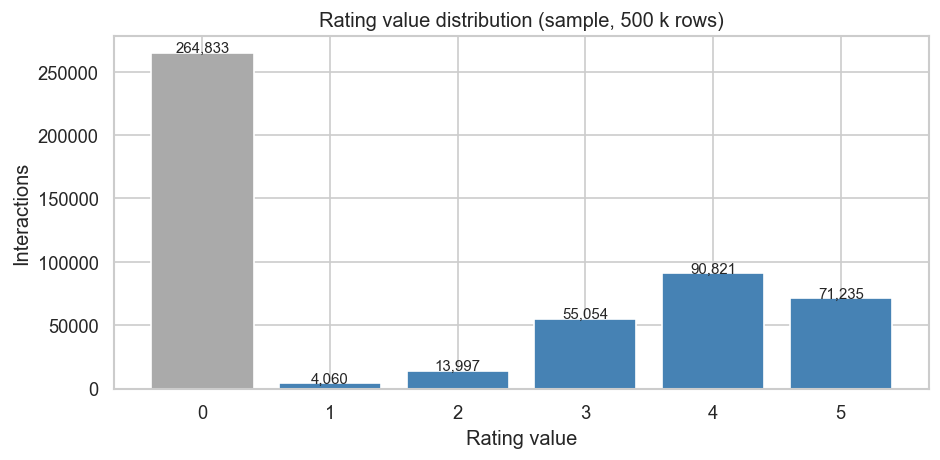

Fraction with explicit rating (rating > 0): 47.0%
Fraction implicit only   (rating = 0)    : 53.0%


In [15]:
rating_counts = interactions_sample["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=["#aaa"] + ["steelblue"] * 5)
ax.set_xlabel("Rating value")
ax.set_ylabel("Interactions")
ax.set_title("Rating value distribution (sample, 500 k rows)")
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

explicit = (interactions_sample["rating"] > 0).mean()
print(f"Fraction with explicit rating (rating > 0): {explicit:.1%}")
print(f"Fraction implicit only   (rating = 0)    : {1 - explicit:.1%}")

### `is_read` vs `is_reviewed` breakdown

In [16]:
cross = pd.crosstab(
    interactions_sample["is_read"],
    interactions_sample["is_reviewed"],
    rownames=["is_read"],
    colnames=["is_reviewed"],
    margins=True,
)
cross_pct = cross.div(cross.loc["All", "All"]) * 100
print("Counts:")
display(cross)
print("\n% of total:")
display(cross_pct.round(1))

Counts:


is_reviewed,0,1,All
is_read,,,
0,248899,536,249435
1,213372,37193,250565
All,462271,37729,500000



% of total:


is_reviewed,0,1,All
is_read,,,
0,49.8,0.1,49.9
1,42.7,7.4,50.1
All,92.5,7.5,100.0


### User activity — interactions per user (long-tail)

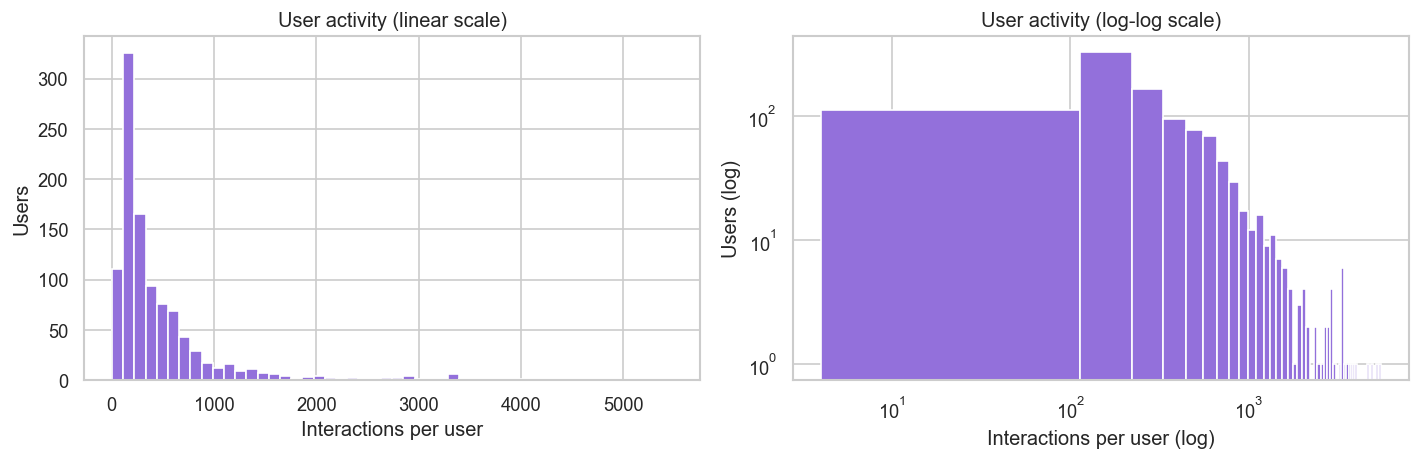

Users in sample         : 1,034
Mean interactions/user  : 483.6
Median interactions/user: 267
Users with only 1 book  : 0.0%


In [17]:
user_activity = interactions_sample["user_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_activity, bins=50, color="mediumpurple", edgecolor="white")
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Users")
axes[0].set_title("User activity (linear scale)")

axes[1].hist(user_activity, bins=50, color="mediumpurple", edgecolor="white", log=True)
axes[1].set_xscale("log")
axes[1].set_xlabel("Interactions per user (log)")
axes[1].set_ylabel("Users (log)")
axes[1].set_title("User activity (log-log scale)")

plt.tight_layout()
plt.show()

print(f"Users in sample         : {len(user_activity):,}")
print(f"Mean interactions/user  : {user_activity.mean():.1f}")
print(f"Median interactions/user: {user_activity.median():.0f}")
print(f"Users with only 1 book  : {(user_activity == 1).mean():.1%}")

### Interaction data — key takeaways

| Observation | Implication |
|---|---|
| ~228 M total interactions, ~876 K users, ~2.36 M books | Matrix density ≈ 0.01 % — extremely sparse, ideal for ALS |
| Majority of rows have `rating = 0` (implicit only) | Both explicit and implicit ALS training modes are viable |
| Long-tail user activity | Apply minimum-interaction filter to remove cold-start users |
| No timestamps | Cannot do temporal train/test splits; use random or leave-one-out |
| `book_id` in interactions is a sequential index | Must join via `book_id_map.csv` to get canonical `work_id` |

# Simplifying the Dataset

We strip the raw books sample down to the columns actually needed for modelling and joining with the interaction data.

**Columns dropped:**
- Bibliographic IDs unused by models: `isbn`, `isbn13`, `asin`, `kindle_asin`
- Redundant / low-signal metadata: `is_ebook`, `series`, `country_code`, `language_code`, `edition_information`
- Aggregate-only feedback (not per-user): `popular_shelves` (already explored above)
- Media / display only: `image_url`, `link` (duplicate of `url`)
- High-missingness date fields not useful for ALS: `publication_month`, `publication_day`
- Superseded by `title_without_series`: raw `title`

**`book_id` is kept** — it is the join key to the interactions data via `book_id_map.csv`.

In [18]:
COLS_TO_DROP = [
    "isbn", "isbn13",
    "asin", "kindle_asin",
    "is_ebook",
    "series",
    "country_code",
    "language_code",
    "popular_shelves",
    "edition_information",
    "image_url",
    "link",
    "publication_month",
    "publication_day",
    "publisher",
    "format",
    "title",           # superseded by title_without_series
]

df_clean = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
df_clean = df_clean.rename(columns={"title_without_series": "title"})

print("Remaining columns:")
print(df_clean.columns.tolist())
print(f"\nShape: {df_clean.shape}")

Remaining columns:
['text_reviews_count', 'average_rating', 'similar_books', 'description', 'authors', 'num_pages', 'publication_year', 'url', 'book_id', 'ratings_count', 'work_id', 'title']

Shape: (100000, 12)


### Extract primary author IDs

The `authors` field is a list of `{author_id, role}` dicts. We flatten it to a plain list of IDs, prioritising entries where `role` is empty string or `'Author'`.

In [19]:
def extract_author_ids(author_list):
    if not isinstance(author_list, list) or len(author_list) == 0:
        return []
    primary = [a["author_id"] for a in author_list
               if isinstance(a, dict) and a.get("role", "") in ("", "Author")]
    return primary if primary else [a["author_id"] for a in author_list if isinstance(a, dict)]

df_clean["author_ids"] = df_clean["authors"].apply(extract_author_ids)
df_clean = df_clean.drop(columns=["authors"])

# Verify a few rows
df_clean[["title", "author_ids"]].head(5)

,title,author_ids
0,W.C. Fields: A Life on Film,[604031]
1,Good Harbor,[626222]
2,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",[10333]
3,Best Friends Forever,[9212]
4,Runic Astrology: Starcraft and Timekeeping in ...,[149918]


### Quality filters

In [20]:
before = len(df_clean)

# Drop books with no canonical work_id
df_clean = df_clean[df_clean["work_id"].notna() & (df_clean["work_id"] != "")]

# Drop books with fewer than 5 ratings (cold-start noise)
df_clean = df_clean[df_clean["ratings_count"] >= 5]

after = len(df_clean)
print(f"Rows before filtering : {before:,}")
print(f"Rows after  filtering : {after:,}")
print(f"Removed               : {before - after:,} ({(before - after) / before:.1%})")

Rows before filtering : 100,000
Rows after  filtering : 78,906
Removed               : 21,094 (21.1%)


### Cleaned dataset summary

In [21]:
print(f"Shape: {df_clean.shape}")
print()
print(df_clean.dtypes)
print()
missing_clean = df_clean.isnull().mean().sort_values(ascending=False) * 100
print("Missing values (%):\n", missing_clean[missing_clean > 0].round(1).to_string())

Shape: (78906, 12)

text_reviews_count    float64
average_rating        float64
similar_books          object
description            object
num_pages             float64
publication_year      float64
url                    object
book_id                object
ratings_count         float64
work_id                object
title                  object
author_ids             object
dtype: object

Missing values (%):
 num_pages           30.3
publication_year    24.8


In [22]:
df_clean.head(3)

,text_reviews_count,average_rating,similar_books,description,num_pages,publication_year,url,book_id,ratings_count,work_id,title,author_ids
1,6.0,3.23,"[8709549, 17074050, 28937, 158816, 228563, 112...","Anita Diamant's international bestseller ""The ...",NaN,2001.0,https://www.goodreads.com/book/show/1333909.Go...,1333909,10.0,1323437,Good Harbor,[626222]
2,7.0,4.03,"[19997, 828466, 1569323, 425389, 1176674, 2627...",Omnibus book club edition containing the Ladie...,600.0,1987.0,https://www.goodreads.com/book/show/7327624-th...,7327624,140.0,8948723,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",[10333]
3,3282.0,3.49,"[6604176, 6054190, 2285777, 82641, 7569453, 70...",Addie Downs and Valerie Adler were eight when ...,368.0,2009.0,https://www.goodreads.com/book/show/6066819-be...,6066819,51184.0,6243154,Best Friends Forever,[9212]


### Save to Parquet

Parquet is chosen for: fast columnar reads, dtype preservation, and ~10× smaller on disk than JSONL.

In [23]:
out_path = "goodreads_books_clean.parquet"
df_clean.to_parquet(out_path, index=False)

# Verify round-trip
df_verify = pd.read_parquet(out_path)
print(f"Saved  : {out_path}")
print(f"Shape  : {df_verify.shape}")
print(f"Columns: {df_verify.columns.tolist()}")

Saved  : goodreads_books_clean.parquet
Shape  : (78906, 12)
Columns: ['text_reviews_count', 'average_rating', 'similar_books', 'description', 'num_pages', 'publication_year', 'url', 'book_id', 'ratings_count', 'work_id', 'title', 'author_ids']
